# 03 — Modelos

Se entrena y evalúa un **baseline pre-entrenado** (TextBlob) y **dos modelos propios**:

| | vectorización | modelo |
|---|---|---|
| Modelo 1 | Bag of Words | Naive Bayes |
| Modelo 2 | TF-IDF | Reg. Logística |

**Cada modelo se mide en tres conjuntos**, y cada uno responde una pregunta distinta:

| conjunto | pregunta |
|---|---|
| **train** (80% de los 1.6M) | ¿cuánto ajusta los datos que vio? |
| **test** (20% de los 1.6M) | ¿generaliza? → **la resta con train mide sobreajuste** |
| **manual** (359, a mano) | ¿coincide con un humano? → **validación externa** |

⚠️ El F1 del set manual **no se resta contra los otros dos**: viene de otro proceso de etiquetado, así que la diferencia no sería un gap.

In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (9, 5)

PROCESSED = Path("..") / "data" / "processed"
MODELS = Path("..") / "models"
MODELS.mkdir(parents=True, exist_ok=True)

# Split de los 1.6M (misma distribucion -> comparables entre si)
tr = pd.read_parquet(PROCESSED / "train_clean.parquet")
te = pd.read_parquet(PROCESSED / "test_clean.parquet")
X_train, y_train = tr["text_clean"], tr["polarity"].map({0: -1, 4: 1})
X_test,  y_test  = te["text_clean"], te["polarity"].map({0: -1, 4: 1})

# Etiquetado a mano: validacion EXTERNA (otra distribucion, se reporta aparte)
man = pd.read_parquet(PROCESSED / "manual_clean.parquet")
man_bin = man[man["polarity"] != 2]
X_man, y_man = man_bin["text_clean"], man_bin["polarity"].map({0: -1, 4: 1})
X_man_full = man["text_clean"]

print(f"train : {len(X_train):>9,}  (80% de los 1.6M)")
print(f"test  : {len(X_test):>9,}  (20% de los 1.6M, misma distribucion)")
print(f"manual: {len(X_man):>9,}  (etiquetado a mano, validacion externa)")

train : 1,276,996  (80% de los 1.6M)
test  :   319,250  (20% de los 1.6M, misma distribucion)
manual:       359  (etiquetado a mano, validacion externa)


## 4. Baseline: modelo pre-entrenado (TextBlob)

**Baseline pedido por la consigna:** ¿qué tan bien predice un modelo genérico pre-entrenado, que **nunca vio un tweet de este dataset**?

TextBlob funciona con un **léxico**: una lista de palabras con polaridad asignada a mano. No se entrena, así que se lo evalúa directamente sobre el **set manual**.

In [2]:
def textblob_pred(texto, umbral=0.05):
    polaridad = TextBlob(texto).sentiment.polarity
    if polaridad > umbral:
        return 1
    elif polaridad < -umbral:
        return -1
    return 0


t0 = time.time()
pred_textblob = X_man.apply(textblob_pred)
print(f"TextBlob sobre {len(X_man)} tweets: {time.time()-t0:.1f}s")

print(classification_report(y_man, pred_textblob, zero_division=0))
acc_textblob = accuracy_score(y_man, pred_textblob)
f1_textblob = f1_score(y_man, pred_textblob, average="macro")


TextBlob sobre 359 tweets: 0.0s
              precision    recall  f1-score   support

          -1       0.87      0.42      0.56       177
           0       0.00      0.00      0.00         0
           1       0.72      0.76      0.74       182

    accuracy                           0.59       359
   macro avg       0.53      0.39      0.43       359
weighted avg       0.79      0.59      0.65       359



In [3]:
# ¿La comparacion es justa? Nuestra funcion usa umbral=0.05, y eso hace que TextBlob
# prediga "neutral" — una clase que el test binario no tiene, o sea, errada de entrada.
# Verificamos si esa decision es la que lo hunde, probando otros umbrales.

print("De los 177 negativos REALES, TextBlob predice:")
print(pred_textblob[y_man == -1].value_counts().sort_index()
      .rename({-1: "negativo (acierta)", 0: "neutral (falla)", 1: "positivo (falla)"}).to_string())

print("\nSensibilidad al umbral:")
for u in [0.0, 0.05, 0.1, 0.2]:
    p = X_man.apply(lambda t: textblob_pred(t, umbral=u))
    print(f"  umbral={u:<5} accuracy={accuracy_score(y_man, p):.4f}  "
          f"F1 macro={f1_score(y_man, p, average='macro'):.4f}  "
          f"neutrales={(p == 0).sum():>3}")

De los 177 negativos REALES, TextBlob predice:
text_clean
negativo (acierta)    74
neutral (falla)       49
positivo (falla)      54

Sensibilidad al umbral:
  umbral=0.0   accuracy=0.5989  F1 macro=0.4370  neutrales= 75
  umbral=0.05  accuracy=0.5905  F1 macro=0.4343  neutrales= 82
  umbral=0.1   accuracy=0.5599  F1 macro=0.4235  neutrales=100


  umbral=0.2   accuracy=0.4708  F1 macro=0.3828  neutrales=149


In [4]:
# ¿Por que falla TextBlob? Miramos la POLARIDAD CRUDA que asigna, antes del umbral.
# La escala va de -1 (maximo negativo) a +1 (maximo positivo); 0 = neutral.
# Para clasificar bien, a un tweet negativo le alcanza con recibir cualquier valor < 0.
polaridades = X_man.apply(lambda t: TextBlob(t).sentiment.polarity)

resumen = polaridades.groupby(y_man.map({-1: "REAL negativo", 1: "REAL positivo"})).agg(["mean", "median"])
print("Polaridad que asigna TextBlob, segun la clase REAL:")
print(resumen.round(3).to_string())

# ¿Le acierta al menos al SIGNO?
print("\n¿Acierta el signo?")
for clase, nombre in [(-1, "negativos"), (1, "positivos")]:
    p = polaridades[y_man == clase]
    bien = (p < 0).sum() if clase == -1 else (p > 0).sum()
    mal  = (p > 0).sum() if clase == -1 else (p < 0).sum()
    cero = (p == 0).sum()
    print(f"  {nombre:>10}: signo correcto {bien:>3} ({bien/len(p)*100:>4.1f}%) | "
          f"signo INVERTIDO {mal:>3} ({mal/len(p)*100:>4.1f}%) | sin señal (0.0) {cero:>3} ({cero/len(p)*100:>4.1f}%)")

# ¿El lexico esta sesgado hacia lo positivo? Lo probamos con palabras sueltas.
print("\n¿Como puntua el lexico las palabras que SI conoce?")
print("  positivas:", {w: TextBlob(w).sentiment.polarity for w in ["good", "love", "great", "happy"]})
print("  negativas:", {w: TextBlob(w).sentiment.polarity for w in ["bad", "sad", "terrible", "awful"]})
print("  -> El lexico es SIMETRICO: good=+0.70 y bad=-0.70. No hay sesgo positivo.")

print("\n¿Y las palabras con las que la gente realmente se queja en Twitter?")
print("  ", {w: TextBlob(w).sentiment.polarity for w in ["aching", "ponzi", "cant"]})
print("  -> Valen 0.00: no estan en el lexico. Ese es el verdadero problema.")

print("\n  Ejemplos de NEGATIVOS que TextBlob no puede leer (polaridad 0.0):")
for t in X_man[(polaridades == 0.0) & (y_man == -1)].head(3):
    print(f"    - {t[:66]!r}")

Polaridad que asigna TextBlob, segun la clase REAL:
                mean  median
polarity                    
REAL negativo -0.058   0.000
REAL positivo  0.335   0.372

¿Acierta el signo?
   negativos: signo correcto  77 (43.5%) | signo INVERTIDO  57 (32.2%) | sin señal (0.0)  43 (24.3%)
   positivos: signo correcto 138 (75.8%) | signo INVERTIDO  12 ( 6.6%) | sin señal (0.0)  32 (17.6%)

¿Como puntua el lexico las palabras que SI conoce?
  positivas: {'good': 0.7, 'love': 0.5, 'great': 0.8, 'happy': 0.8}
  negativas: {'bad': -0.6999999999999998, 'sad': -0.5, 'terrible': -1.0, 'awful': -1.0}
  -> El lexico es SIMETRICO: good=+0.70 y bad=-0.70. No hay sesgo positivo.

¿Y las palabras con las que la gente realmente se queja en Twitter?
   {'aching': 0.0, 'ponzi': 0.0, 'cant': 0.0}
  -> Valen 0.00: no estan en el lexico. Ese es el verdadero problema.

  Ejemplos de NEGATIVOS que TextBlob no puede leer (polaridad 0.0):
    - "lebron is a beast but i'm still cheering the a til the end"
    -

**Conclusión — TextBlob: 0.59 accuracy / 0.43 F1**

Contra un azar de 0.50, **apenas le gana a una moneda**. Es el piso a superar.

**Es casi ciego a lo negativo:**

| clase real | polaridad mediana | acierta el signo |
|---|---|---|
| negativo | **0.000** | 43% |
| positivo | +0.372 | 76% |

**El culpable NO es el léxico — es simétrico:** `good`=+0.70, `bad`=**−0.70**.

**El culpable es el lenguaje:** nadie tuitea *"bad"*. La gente se queja con `aching`, `ponzi`, `cant` → **valen 0.00, no están en la lista**.

**¿Comparación injusta?** Se midió: con el mejor umbral llega a 0.5989. **El umbral no lo salva** — es problema de dominio.

## 5. Modelo 1: Bag of Words + Naive Bayes

In [5]:
t0 = time.time()
vec_bow = CountVectorizer(min_df=5, max_features=50000)
X_train_bow = vec_bow.fit_transform(X_train)   # fit SOLO con train
X_test_bow  = vec_bow.transform(X_test)        # test interno: solo transform
X_man_bow   = vec_bow.transform(X_man)         # set manual:   solo transform
print(f"Vectorización BoW ({X_train_bow.shape[1]} features): {time.time()-t0:.1f}s")

t0 = time.time()
nb = MultinomialNB()
nb.fit(X_train_bow, y_train)
print(f"Entrenamiento ({len(X_train):,} filas): {time.time()-t0:.1f}s")

f1_nb_train = f1_score(y_train, nb.predict(X_train_bow), average="macro")
f1_nb_test  = f1_score(y_test,  nb.predict(X_test_bow),  average="macro")
f1_nb_man   = f1_score(y_man,   nb.predict(X_man_bow),   average="macro")
acc_nb_man  = accuracy_score(y_man, nb.predict(X_man_bow))

print(f"\n--- Sobreajuste: train vs test (misma distribución) ---")
print(f"  F1 macro train : {f1_nb_train:.4f}")
print(f"  F1 macro test  : {f1_nb_test:.4f}")
print(f"  GAP            : {f1_nb_train - f1_nb_test:+.4f}")
print(f"\n--- Validación externa: set etiquetado a mano ---")
print(f"  F1 macro       : {f1_nb_man:.4f}   (no se resta contra los de arriba)")
print()
print(classification_report(y_man, nb.predict(X_man_bow), zero_division=0))

Vectorización BoW (45139 features): 8.2s
Entrenamiento (1,276,996 filas): 0.1s



--- Sobreajuste: train vs test (misma distribución) ---
  F1 macro train : 0.7910
  F1 macro test  : 0.7825
  GAP            : +0.0086

--- Validación externa: set etiquetado a mano ---
  F1 macro       : 0.8273   (no se resta contra los de arriba)

              precision    recall  f1-score   support

          -1       0.82      0.82      0.82       177
           1       0.83      0.83      0.83       182

    accuracy                           0.83       359
   macro avg       0.83      0.83      0.83       359
weighted avg       0.83      0.83      0.83       359



**Conclusión — BoW + Naive Bayes**

**Sobreajuste** (train vs test, misma distribución → comparables):

| train | test | **gap** |
|---|---|---|
| 0.7910 | 0.7825 | **+0.0086** |

- **El gap es ~0.009: prácticamente cero → no hay sobreajuste.**
- Esperable: Naive Bayes sobre 50.000 features y 1.3M de ejemplos es demasiado simple para memorizar. Si algo, está *subajustado*.

**Validación externa** (set etiquetado a mano): **F1 = 0.8273**

- 🔍 **Rinde MEJOR con humanos (0.83) que en su propio test interno (0.78).**
- **¿Por qué?** Las etiquetas de train son **automáticas** (un `:)` = positivo, sin que nadie lo lea): traen sarcasmo, ironía, emoticones de costumbre. El modelo no puede superar el 79% en su propia distribución porque **esas etiquetas se contradicen entre sí**.
- → El techo del 79% no es del modelo: **es el ruido del etiquetado**. Con etiquetas limpias, el mismo modelo llega a 0.83. (*weak supervision*)

## 6. Modelo 2: TF-IDF + Regresión Logística

In [6]:
t0 = time.time()
vec_tfidf = TfidfVectorizer(min_df=5, max_features=50000)
X_train_tfidf = vec_tfidf.fit_transform(X_train)   # fit SOLO con train
X_test_tfidf  = vec_tfidf.transform(X_test)        # test interno: solo transform
X_man_tfidf   = vec_tfidf.transform(X_man)         # set manual:   solo transform
print(f"Vectorización TF-IDF: {time.time()-t0:.1f}s")

t0 = time.time()
lr = LogisticRegression(max_iter=200)
lr.fit(X_train_tfidf, y_train)
print(f"Entrenamiento ({len(X_train):,} filas): {time.time()-t0:.1f}s")

f1_lr_train = f1_score(y_train, lr.predict(X_train_tfidf), average="macro")
f1_lr_test  = f1_score(y_test,  lr.predict(X_test_tfidf),  average="macro")
f1_lr_man   = f1_score(y_man,   lr.predict(X_man_tfidf),   average="macro")
acc_lr_man  = accuracy_score(y_man, lr.predict(X_man_tfidf))

print(f"\n--- Sobreajuste: train vs test (misma distribución) ---")
print(f"  F1 macro train : {f1_lr_train:.4f}")
print(f"  F1 macro test  : {f1_lr_test:.4f}")
print(f"  GAP            : {f1_lr_train - f1_lr_test:+.4f}")
print(f"\n--- Validación externa: set etiquetado a mano ---")
print(f"  F1 macro       : {f1_lr_man:.4f}   (no se resta contra los de arriba)")
print()
print(classification_report(y_man, lr.predict(X_man_tfidf), zero_division=0))

Vectorización TF-IDF: 8.6s


Entrenamiento (1,276,996 filas): 10.5s



--- Sobreajuste: train vs test (misma distribución) ---
  F1 macro train : 0.8068
  F1 macro test  : 0.8000
  GAP            : +0.0068

--- Validación externa: set etiquetado a mano ---
  F1 macro       : 0.8215   (no se resta contra los de arriba)

              precision    recall  f1-score   support

          -1       0.83      0.80      0.82       177
           1       0.81      0.85      0.83       182

    accuracy                           0.82       359
   macro avg       0.82      0.82      0.82       359
weighted avg       0.82      0.82      0.82       359



**Conclusión — TF-IDF + Regresión Logística**

**Sobreajuste** (train vs test, misma distribución):

| train | test | **gap** |
|---|---|---|
| 0.8068 | 0.8000 | **+0.0068** |

- **Gap ~0.007 → tampoco sobreajusta.**

**Validación externa** (set a mano): **F1 = 0.8215**

- Se repite el patrón: **mejor con humanos (0.82) que en su test interno (0.80)** → confirma el ruido de las etiquetas automáticas.

**Contra Naive Bayes:**

| | test interno (319.250 tweets) | set manual (359 tweets) |
|---|---|---|
| Naive Bayes | 0.7825 | **0.8273** |
| Reg. Logística | **0.8000** | 0.8215 |

- 🔍 **En el test interno gana la Reg. Logística por 0.018** — y ahí la diferencia **sí es confiable**, porque se mide sobre **319.250 tweets**, no sobre 359.
- En el set manual gana Naive Bayes por 0.006... que son **~2 tweets**. Ruido.
- → **Con poder estadístico, la Reg. Logística es mejor.** Tiene sentido: es discriminativa (optimiza la frontera) y no asume independencia entre palabras.

## 7. Comparación de modelos

,F1 train,F1 test (interno),Gap,F1 set manual
Modelo,,,,
TextBlob (pre-entrenado),—,—,—,0.4343
BoW + Naive Bayes,0.7910,0.7825,0.0086,0.8273
TF-IDF + Reg. Logística,0.8068,0.8000,0.0068,0.8215


/tmp/ipykernel_2521912/756518669.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[1].set_xticklabels(comparacion.index, rotation=10, fontsize=8)


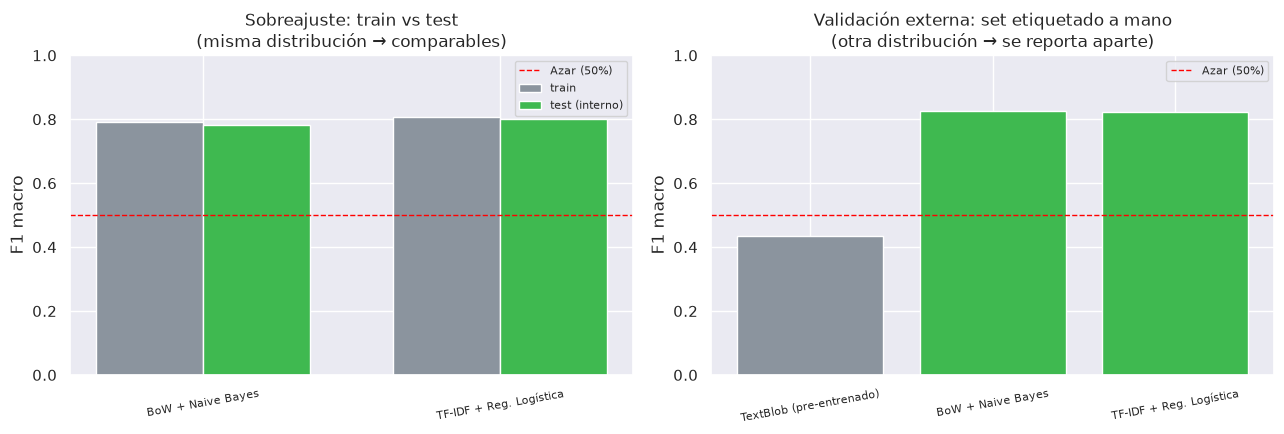

In [7]:
comparacion = pd.DataFrame({
    "Modelo": ["TextBlob (pre-entrenado)", "BoW + Naive Bayes", "TF-IDF + Reg. Logística"],
    "F1 train": [np.nan, f1_nb_train, f1_lr_train],
    "F1 test (interno)": [np.nan, f1_nb_test, f1_lr_test],
    "Gap": [np.nan, f1_nb_train - f1_nb_test, f1_lr_train - f1_lr_test],
    "F1 set manual": [f1_textblob, f1_nb_man, f1_lr_man],
}).set_index("Modelo")

display(comparacion.style.format("{:.4f}", na_rep="—")
        .background_gradient(cmap="Greens", subset=["F1 test (interno)", "F1 set manual"]))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# Izquierda: sobreajuste (solo los entrenados: TextBlob no tiene train)
sub = comparacion.dropna(subset=["F1 train"])
x = np.arange(len(sub)); w = 0.36
ax[0].bar(x - w/2, sub["F1 train"], w, label="train", color="#8B949E")
ax[0].bar(x + w/2, sub["F1 test (interno)"], w, label="test (interno)", color="#3FB950")
ax[0].set_xticks(x); ax[0].set_xticklabels(sub.index, rotation=10, fontsize=8)
ax[0].set_ylim(0, 1); ax[0].set_ylabel("F1 macro")
ax[0].axhline(0.5, ls="--", color="red", lw=1, label="Azar (50%)")
ax[0].set_title("Sobreajuste: train vs test\n(misma distribución → comparables)")
ax[0].legend(fontsize=8)

# Derecha: validacion externa (aca SI entra TextBlob)
ax[1].bar(comparacion.index, comparacion["F1 set manual"],
          color=["#8B949E", "#3FB950", "#3FB950"])
ax[1].axhline(0.5, ls="--", color="red", lw=1, label="Azar (50%)")
ax[1].set_ylim(0, 1); ax[1].set_ylabel("F1 macro")
ax[1].set_xticklabels(comparacion.index, rotation=10, fontsize=8)
ax[1].set_title("Validación externa: set etiquetado a mano\n(otra distribución → se reporta aparte)")
ax[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Conclusión**

**1. Ninguno sobreajusta.** Los gaps son +0.009 y +0.007 — prácticamente cero. Medido como corresponde: train contra test de **la misma distribución**.

**2. Gana la Regresión Logística** (0.8000 vs 0.7825 en el test interno). La diferencia de 0.018 se mide sobre **319.250 tweets** → es confiable. *(En el set manual el orden se invierte, pero por 0.006 sobre 359 tweets: eso es ruido.)*

**3. Entrenar sobre el dominio le gana por lejos al pre-entrenado:** 0.82 vs 0.43 de F1 sobre el mismo set manual.

**4. 🔍 Los dos modelos rinden MEJOR con etiquetas humanas que con las suyas propias** (0.83 vs 0.78 | 0.82 vs 0.80). Es la evidencia del *weak supervision*: **el techo lo pone el ruido del etiquetado automático, no el modelo**.

*Referencia: el paper original de Sentiment140 (2009) reporta ~0.83 con Naive Bayes sobre el set manual. Estamos en línea.*

## 8. ¿Y contra el test completo, con la clase neutral?

In [8]:
# ¿Y si evaluamos contra el set manual COMPLETO, incluyendo la clase neutral
# (que ningun modelo puede predecir, porque no existe en el train)?
X_man_full_bow = vec_bow.transform(X_man_full)
y_man_full = man["polarity"].map({0: -1, 2: 0, 4: 1})

print("BoW + Naive Bayes contra el set manual COMPLETO (incluye neutral):")
print(classification_report(y_man_full, nb.predict(X_man_full_bow), zero_division=0))

BoW + Naive Bayes contra el set manual COMPLETO (incluye neutral):


              precision    recall  f1-score   support

          -1       0.67      0.82      0.74       177
           0       0.00      0.00      0.00       139
           1       0.54      0.83      0.66       182

    accuracy                           0.60       498
   macro avg       0.40      0.55      0.46       498
weighted avg       0.43      0.60      0.50       498



**Conclusión.** La clase neutral tiene **recall 0**: el modelo nunca puede predecirla porque no la vio nunca.

- Contra el test binario: **0.82** de accuracy.
- Contra el test completo: **0.59**.

→ **Es una limitación del dataset, no del modelo.** Ningún algoritmo lo resuelve — haría falta etiquetar datos a mano.

## 9. Guardado

In [9]:
joblib.dump(vec_bow, MODELS / "vec_bow.joblib")
joblib.dump(vec_tfidf, MODELS / "vec_tfidf.joblib")
joblib.dump(nb, MODELS / "nb.joblib")
joblib.dump(lr, MODELS / "lr.joblib")
joblib.dump({
    "textblob":      {"accuracy_manual": acc_textblob, "f1_manual": f1_textblob},
    "naive_bayes":   {"f1_train": f1_nb_train, "f1_test": f1_nb_test,
                      "gap": f1_nb_train - f1_nb_test, "f1_manual": f1_nb_man},
    "reg_logistica": {"f1_train": f1_lr_train, "f1_test": f1_lr_test,
                      "gap": f1_lr_train - f1_lr_test, "f1_manual": f1_lr_man},
}, MODELS / "metricas.joblib")

print("Guardados en", MODELS.resolve())
print("  vec_bow | vec_tfidf | nb | lr | metricas")

Guardados en /home/matias/clases-diplomatura/tp3-nlp-tweets/models
  vec_bow | vec_tfidf | nb | lr | metricas
